In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd '/content/drive/MyDrive/2023-01/경영ai캡스톤'

Mounted at /content/drive
/content/drive/MyDrive/2023-01/경영ai캡스톤


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('FINAL.csv')
df=df.drop('Unnamed: 0', axis=1)

In [4]:
df

,title,artist,Top_Rank,chartIns,chart_likes,top10,Video_id,MV,release_date,category_id,...,chroma_max,chroma_range,chroma_std,mfcc_mean,mfcc_std,mfcc_min,mfcc_max,duration(sec),ChartIn_Date,days_to_chart
0,심술,볼빨간사춘기,4,84,150432,1,olieJ1V6ulo,0.0,2022-09-05,10,...,1.0,1.000000,0.317685,0.432475,51.089466,-491.914642,220.290131,158.0,2017-01-01,-2069
1,You(=I),볼빨간사춘기,5,69,123889,1,B6mI1mVMAB4,0.0,2022-06-15,10,...,1.0,1.000000,0.291205,3.352938,45.579376,-470.125824,232.687866,170.0,2017-01-01,-1977
2,안아줘,정준일,6,75,228949,1,YPBeItQC2Cw,1.0,2017-11-18,10,...,1.0,0.999767,0.295621,-0.534902,62.603970,-514.322144,239.799149,275.0,2017-01-01,-304
3,The Time Goes On,BewhY (비와이),10,29,107344,1,mcjR94Q1qSI,1.0,2015-03-14,10,...,1.0,1.000000,0.295709,-4.405906,65.290169,-609.741333,258.781799,311.0,2017-01-01,672
4,잠깐만요,어쿠루브,11,8,23470,0,_mcPQtCLMK8,0.0,2017-11-10,22,...,1.0,1.000000,0.313364,-1.312540,57.235828,-498.101593,209.287201,226.0,2017-01-01,-304
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
567,헤어졌죠,이준호,83,1,2100,0,TOu1sDFUhXo,0.0,2023-01-31,10,...,1.0,1.000000,0.307158,0.780109,58.439999,-523.479919,235.376404,267.0,2023-02-01,31
568,널 떠올리는 중이야,"PATEKO (파테코), Jayci yucca (제이씨 유카), Kid Wine",17,19,56412,0,HcOuoNgrhFg,0.0,2021-07-25,10,...,1.0,0.999675,0.301545,-0.888143,51.411983,-493.338745,229.958023,196.0,2023-03-01,608
569,yours,데이먼스 이어 (Damons year),34,22,89529,0,VHj6IYA-Dxs,0.0,2019-04-10,10,...,1.0,1.000000,0.304957,2.643367,57.411804,-491.321472,232.210892,166.0,2023-03-01,1430
570,사랑해줘요,피아노맨,41,1,2675,0,zGnod7AjTWU,0.0,2023-03-05,10,...,1.0,0.999702,0.320932,1.755025,53.773403,-480.173492,211.116348,238.0,2023-03-01,0


In [5]:
df['duration(sec)'] = df['duration(sec)'].fillna(0)

In [6]:
# Convert 'chartIn_Date' column to datetime type
df['ChartIn_Date'] = pd.to_datetime(df['ChartIn_Date'])

# EDA

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 31 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   title          572 non-null    object        
 1   artist         572 non-null    object        
 2   Top_Rank       572 non-null    int64         
 3   chartIns       572 non-null    int64         
 4   chart_likes    572 non-null    int64         
 5   top10          572 non-null    int64         
 6   Video_id       572 non-null    object        
 7   MV             572 non-null    float64       
 8   release_date   572 non-null    object        
 9   category_id    572 non-null    int64         
 10  views          572 non-null    int64         
 11  YT_likes       572 non-null    int64         
 12  comments       572 non-null    int64         
 13  tempo          572 non-null    float64       
 14  beat_max       572 non-null    float64       
 15  beat_min       572 non-

In [8]:
df.describe()

,Top_Rank,chartIns,chart_likes,top10,MV,category_id,views,YT_likes,comments,tempo,...,chroma_min,chroma_max,chroma_range,chroma_std,mfcc_mean,mfcc_std,mfcc_min,mfcc_max,duration(sec),days_to_chart
count,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,5.720000e+02,5.720000e+02,572.000000,572.000000,...,572.000000,572.0,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000
mean,47.043706,9.003497,33753.854895,0.146853,0.419580,11.944056,2.996881e+06,2.281703e+04,726.506993,118.922539,...,0.000174,1.0,0.999826,0.307246,0.054587,54.910052,-491.412104,229.977275,225.763986,-176.755245
std,30.349624,15.877817,48434.836209,0.354269,0.493922,4.797513,8.951475e+06,1.087934e+05,3314.826213,28.223474,...,0.000486,0.0,0.000486,0.009782,3.092833,7.823318,20.614596,14.643506,49.954044,669.271525
min,1.000000,1.000000,1632.000000,0.000000,0.000000,10.000000,6.800000e+01,0.000000e+00,0.000000,64.599609,...,0.000000,1.0,0.994884,0.266914,-10.637625,36.133224,-623.472839,178.910706,0.000000,-2222.000000
25%,20.000000,1.000000,7657.000000,0.000000,0.000000,10.000000,1.151858e+05,9.567500e+02,4.000000,95.703125,...,0.000000,1.0,0.999888,0.301673,-1.726820,49.664547,-501.824013,220.036190,201.000000,-342.500000
50%,44.000000,2.000000,15769.500000,0.000000,0.000000,10.000000,3.832315e+05,3.820000e+03,51.000000,120.185320,...,0.000000,1.0,1.000000,0.307703,0.344834,54.602306,-489.262268,230.202957,224.000000,0.000000
75%,75.000000,7.000000,35863.500000,0.000000,1.000000,10.000000,2.090032e+06,1.604775e+04,277.250000,135.999178,...,0.000112,1.0,1.000000,0.313476,2.155894,59.848198,-478.230545,239.365910,252.250000,31.000000
max,100.000000,84.000000,355126.000000,1.000000,1.000000,24.000000,1.209478e+08,2.229688e+06,50685.000000,198.768029,...,0.005116,1.0,1.000000,0.336774,7.691269,83.496147,-447.357422,275.834808,365.000000,3896.000000


In [9]:
df.iloc[:, 17:].describe()

,beat_range,beat_std,chroma_mean,chroma_min,chroma_max,chroma_range,chroma_std,mfcc_mean,mfcc_std,mfcc_min,mfcc_max,duration(sec),days_to_chart
count,572.000000,572.000000,572.000000,572.000000,572.0,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000
mean,18596.473776,5381.535686,0.389380,0.000174,1.0,0.999826,0.307246,0.054587,54.910052,-491.412104,229.977275,225.763986,-176.755245
std,3396.431484,979.765604,0.051039,0.000486,0.0,0.000486,0.009782,3.092833,7.823318,20.614596,14.643506,49.954044,669.271525
min,4652.000000,1357.545044,0.255281,0.000000,1.0,0.994884,0.266914,-10.637625,36.133224,-623.472839,178.910706,0.000000,-2222.000000
25%,16389.750000,4742.048478,0.356324,0.000000,1.0,0.999888,0.301673,-1.726820,49.664547,-501.824013,220.036190,201.000000,-342.500000
50%,18223.000000,5276.877010,0.383339,0.000000,1.0,1.000000,0.307703,0.344834,54.602306,-489.262268,230.202957,224.000000,0.000000
75%,20540.000000,5936.275199,0.417678,0.000112,1.0,1.000000,0.313476,2.155894,59.848198,-478.230545,239.365910,252.250000,31.000000
max,31112.000000,8991.400463,0.580829,0.005116,1.0,1.000000,0.336774,7.691269,83.496147,-447.357422,275.834808,365.000000,3896.000000


<ipython-input-10-eb2f13f5907b>:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = df.corr()


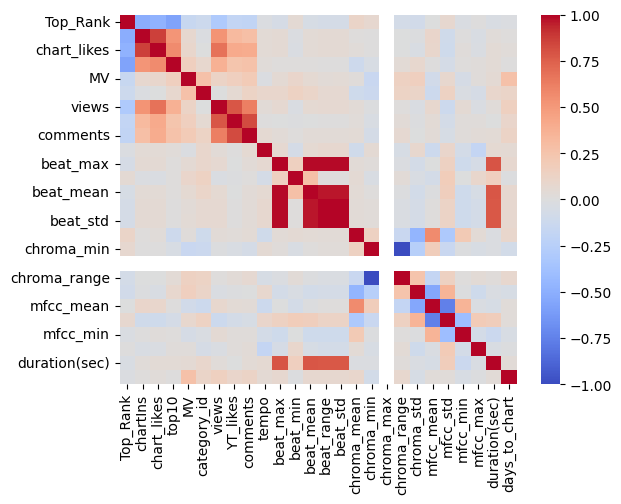

In [10]:
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, cmap='coolwarm')
plt.show()

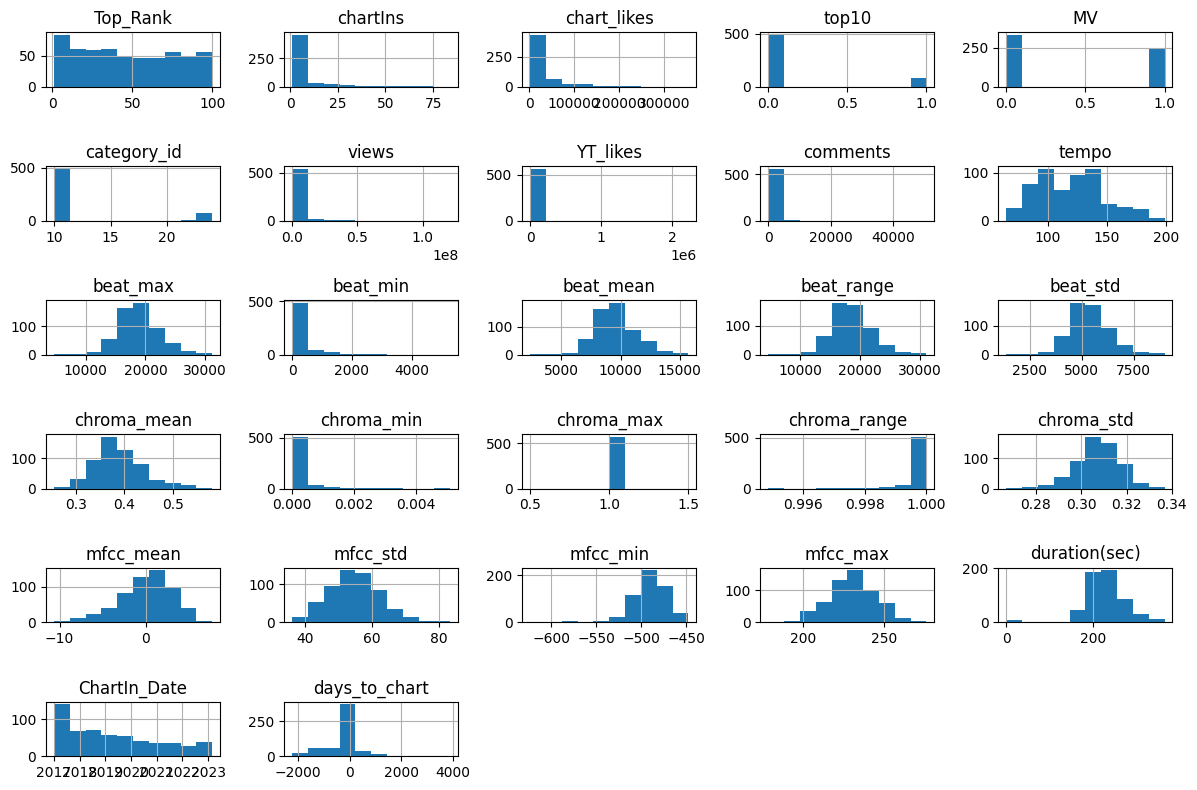

In [11]:
df.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

<ipython-input-12-36b5725589d3>:19: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(Non_top_10[feature], shade=True, label='top10: 0', ax=ax)
<ipython-input-12-36b5725589d3>:20: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(Top_10[feature], shade=True, label='top10: 1', ax=ax)
<ipython-input-12-36b5725589d3>:19: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(Non_top_10[feature], shade=True, label='top10: 0', ax=ax)
<ipython-input-12-36b5725589d3>:20: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(Top_10

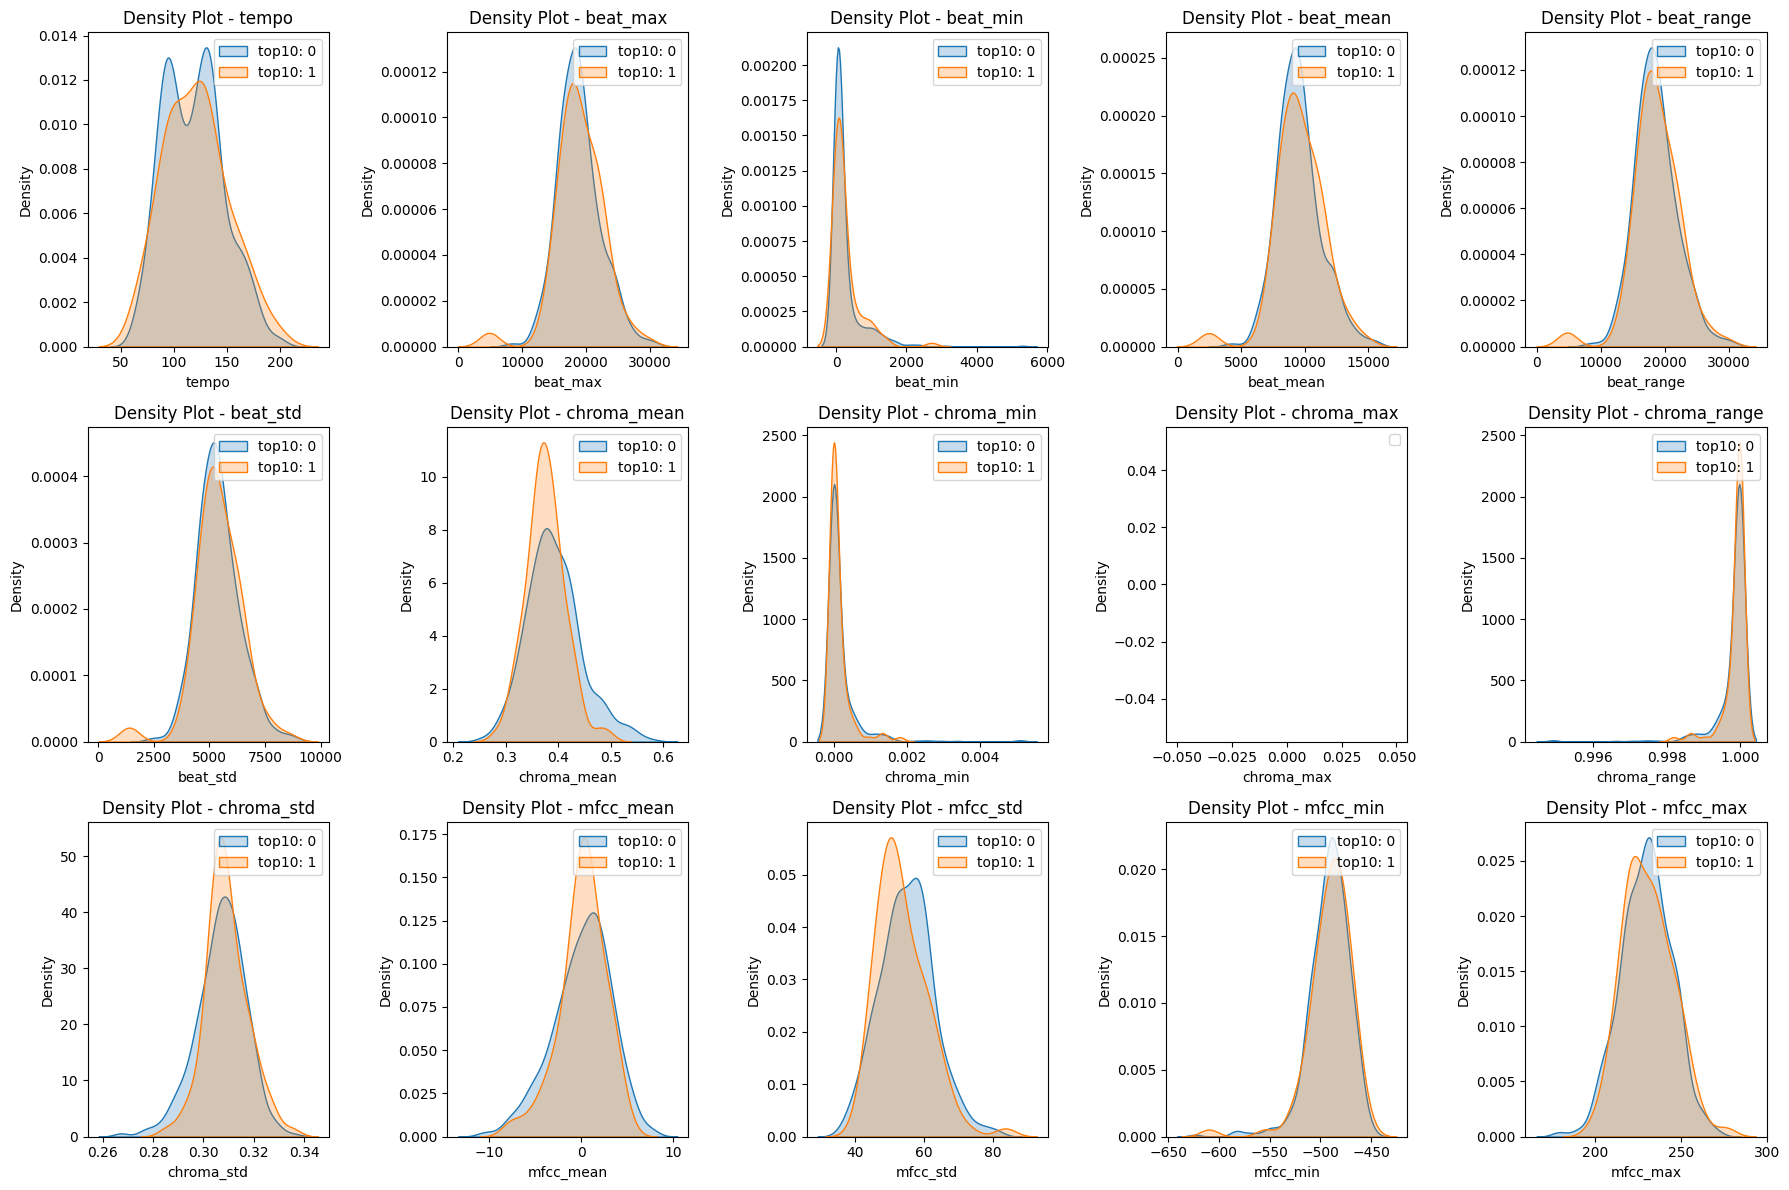

In [12]:
# Filter the dataset based on 'top10' category
Non_top_10 = df[df['top10'] == 0]
Top_10 = df[df['top10'] == 1]

# Select the main acoustic features
acoustic_features = ['tempo', 'beat_max', 'beat_min', 'beat_mean', 'beat_range', 'beat_std',
                     'chroma_mean', 'chroma_min', 'chroma_max', 'chroma_range', 'chroma_std',
                     'mfcc_mean', 'mfcc_std', 'mfcc_min', 'mfcc_max']

# Create a 3x5 grid of subplots for density plots
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(18, 12))

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Create density plots for each acoustic feature as subplots
for i, feature in enumerate(acoustic_features):
    ax = axes[i]
    sns.kdeplot(Non_top_10[feature], shade=True, label='top10: 0', ax=ax)
    sns.kdeplot(Top_10[feature], shade=True, label='top10: 1', ax=ax)
    ax.set_title(f'Density Plot - {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Density')
    ax.legend()

# Hide the empty subplots if there are fewer features than subplots
if len(acoustic_features) < len(axes):
    for j in range(len(acoustic_features), len(axes)):
        axes[j].axis('off')

# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()

# Analysis

In [13]:
#import libraries
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier,GradientBoostingClassifier
from sklearn.svm import SVR
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report,accuracy_score
import xgboost as xgb
from sklearn.model_selection import cross_val_score

! pip install shap
import shap

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 kB 10.8 MB/s eta 0:00:00


## View

In [14]:
# View- both
# Select the relevant features and target variable
X = df[['Top_Rank','chartIns','chart_likes','MV','category_id', 'YT_likes', 'comments', 'top10', 'duration(sec)',
        'tempo', 'beat_max', 'beat_min', 'beat_mean', 'beat_range', 'beat_std', 'chroma_mean', 'chroma_min', 'chroma_max', 'chroma_range', 'chroma_std',
        'mfcc_mean', 'mfcc_std', 'mfcc_min', 'mfcc_max']]
y = np.log(df['views'])

In [15]:
# View- musical
X = df[['tempo', 'beat_max', 'beat_min', 'beat_mean', 'beat_range', 'beat_std', 'chroma_mean', 'chroma_min', 'chroma_max', 'chroma_range', 'chroma_std', 'mfcc_mean', 'mfcc_std', 'mfcc_min', 'mfcc_max']]
y = np.log(df['views'])

In [16]:
# View-YT
X = df[['Top_Rank','chartIns','chart_likes','MV','category_id', 'YT_likes', 'comments', 'top10', 'duration(sec)']]
y = np.log(df['views'])

In [17]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and fit the linear regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

# Create and fit the random forest regression model
rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Create and fit the support vector regression model
svm_model = SVR()
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

# Create and fit the XGBoost regression model
xgb_model = xgb.XGBRegressor()
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# Calculate evaluation metrics for each model
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)
mape_linear = np.mean(np.abs((y_test - y_pred_linear) / y_test)) * 100

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
mape_rf = np.mean(np.abs((y_test - y_pred_rf) / y_test)) * 100

rmse_svm = np.sqrt(mean_squared_error(y_test, y_pred_svm))
r2_svm = r2_score(y_test, y_pred_svm)
mape_svm = np.mean(np.abs((y_test - y_pred_svm) / y_test)) * 100

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)
mape_xgb = np.mean(np.abs((y_test - y_pred_xgb) / y_test)) * 100

# Print the evaluation metrics for each model
print("Linear Regression:")
print("RMSE:", rmse_linear)
print("R-squared:", r2_linear)
print("MAPE:", mape_linear)
print()

print("Random Forest Regression:")
print("RMSE:", rmse_rf)
print("R-squared:", r2_rf)
print("MAPE:", mape_rf)
print()

print("Support Vector Regression:")
print("RMSE:", rmse_svm)
print("R-squared:", r2_svm)
print("MAPE:", mape_svm)
print()

print("XGBoost:")
print("RMSE:", rmse_xgb)
print("R-squared:", r2_xgb)
print("MAPE:", mape_xgb)
print()

Linear Regression:
RMSE: 1.5480112507390467
R-squared: 0.35992730486365454
MAPE: 9.233715293532843

Random Forest Regression:
RMSE: 0.6481215460165849
R-squared: 0.8877997062114643
MAPE: 3.2436313143368647

Support Vector Regression:
RMSE: 1.0096261487555866
R-squared: 0.7277284551099614
MAPE: 6.088947607132611

XGBoost:
RMSE: 0.6552639620979701
R-squared: 0.8853131452567362
MAPE: 3.627790998623136



## Rank

In [18]:
# Rank- both
X = df[['views','chartIns','chart_likes','MV','category_id', 'YT_likes', 'comments', 'top10', 'duration(sec)',
        'tempo', 'beat_max', 'beat_min', 'beat_mean', 'beat_range', 'beat_std', 'chroma_mean', 'chroma_min', 'chroma_max', 'chroma_range', 'chroma_std',
        'mfcc_mean', 'mfcc_std', 'mfcc_min', 'mfcc_max']]
y = df['Top_Rank']

In [19]:
# Rank- musical
X = df[['tempo', 'beat_max', 'beat_min', 'beat_mean', 'beat_range', 'beat_std', 'chroma_mean', 'chroma_min', 'chroma_max', 'chroma_range', 'chroma_std', 'mfcc_mean', 'mfcc_std', 'mfcc_min', 'mfcc_max']]
y = df['Top_Rank']

In [20]:
# rank- YT
X = df[['views','chartIns','chart_likes','MV','category_id', 'YT_likes', 'comments', 'top10', 'duration(sec)']]
y = np.log(df['Top_Rank'])

In [21]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and fit the linear regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

# Create and fit the random forest regression model
rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Create and fit the support vector regression model
svm_model = SVR()
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

# Create and fit the XGBoost regression model
xgb_model = xgb.XGBRegressor()
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# Calculate evaluation metrics for each model
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)
mape_linear = np.mean(np.abs((y_test - y_pred_linear) / y_test)) * 100

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
mape_rf = np.mean(np.abs((y_test - y_pred_rf) / y_test)) * 100

rmse_svm = np.sqrt(mean_squared_error(y_test, y_pred_svm))
r2_svm = r2_score(y_test, y_pred_svm)
mape_svm = np.mean(np.abs((y_test - y_pred_svm) / y_test)) * 100

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)
mape_xgb = np.mean(np.abs((y_test - y_pred_xgb) / y_test)) * 100

# Print the evaluation metrics for each model
print("Linear Regression:")
print("RMSE:", rmse_linear)
print("R-squared:", r2_linear)
print("MAPE:", mape_linear)
print()

print("Random Forest Regression:")
print("RMSE:", rmse_rf)
print("R-squared:", r2_rf)
print("MAPE:", mape_rf)
print()

print("Support Vector Regression:")
print("RMSE:", rmse_svm)
print("R-squared:", r2_svm)
print("MAPE:", mape_svm)
print()

print("XGBoost:")
print("RMSE:", rmse_xgb)
print("R-squared:", r2_xgb)
print("MAPE:", mape_xgb)
print()

Linear Regression:
RMSE: 0.6092399956980964
R-squared: 0.7298685685683166
MAPE: inf

Random Forest Regression:
RMSE: 0.5108313043138046
R-squared: 0.8100876035391891
MAPE: inf

Support Vector Regression:
RMSE: 1.0538550591202485
R-squared: 0.19172326845247456
MAPE: inf

XGBoost:
RMSE: 0.5166261121147346
R-squared: 0.8057544789678351
MAPE: inf



## Feature importance/ stepwise




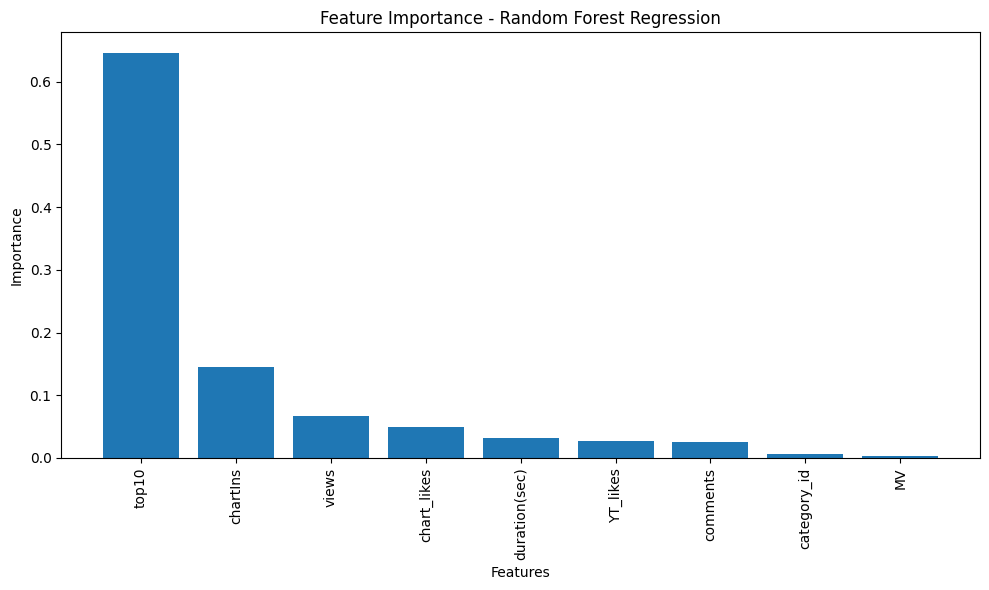

In [22]:
#RF feature
# Get feature importances
importances = rf_model.feature_importances_

# Get the names of the features
feature_names = X.columns

# Sort feature importances in descending order
indices = np.argsort(importances)[::-1]

# Rearrange feature names based on feature importances
sorted_feature_names = [feature_names[i] for i in indices]

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.bar(range(X.shape[1]), importances[indices])
plt.xticks(range(X.shape[1]), sorted_feature_names, rotation=90)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance - Random Forest Regression')
plt.tight_layout()
plt.show()

In [23]:
# Feature selection
# Select the relevant features and target variable
X = df[['chart_likes', 'mfcc_max', 'chartIns', 'top10', 'views']]
y = df['Top_Rank']

In [24]:
#stepwise
import statsmodels.api as sm

# Add a constant column to the feature matrix
X = sm.add_constant(X)

# Create a function for stepwise regression
def stepwise_selection(X, y,
                       initial_list=[],
                       threshold_in=0.05,
                       threshold_out=0.05,
                       verbose=True):
    included = list(initial_list)
    while True:
        changed = False

        # Forward step
        excluded = list(set(X.columns) - set(included))
        new_pval = pd.Series(index=excluded, dtype=float)
        for new_column in excluded:
            model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included + [new_column]]))).fit()
            new_pval[new_column] = model.pvalues[new_column]
        best_pval = new_pval.min()
        if best_pval < threshold_in:
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            changed = True
            if verbose:
                print('Add  {:30} with p-value {:.6}'.format(best_feature, best_pval))

        # Backward step
        model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included]))).fit()
        pvalues = model.pvalues.iloc[1:]
        worst_pval = pvalues.max()
        if worst_pval > threshold_out:
            worst_feature = pvalues.idxmax()
            included.remove(worst_feature)
            changed = True
            if verbose:
                print('Drop {:30} with p-value {:.6}'.format(worst_feature, worst_pval))

        if not changed:
            break

    return included

# Perform stepwise regression
selected_features = stepwise_selection(X, y)

# Fit the Linear Regression model with selected features
model = sm.OLS(y, sm.add_constant(X[selected_features])).fit()

# Get feature importance (coefficients)
feature_importance = model.params.iloc[1:]  # Exclude the constant term

# Sort feature importance in descending order
sorted_feature_importance = feature_importance.abs().sort_values(ascending=False)

# Print feature importance
print(sorted_feature_importance)

Add  const                          with p-value 4.07666e-154
Add  top10                          with p-value 1.24274e-51
Add  chartIns                       with p-value 5.66295e-14
top10       36.177607
chartIns     0.562540
dtype: float64


In [25]:
# View- stepwise
# Select the relevant features and target variable
X = df[['chroma_max','chart_likes','chroma_mean','MV','Top_Rank', 'YT_likes', 'chroma_range', 'mfcc_std',
        'beat_mean', 'mfcc_mean']]
y = np.log(df['views'])

## top 10 prediction

In [26]:
#YT+acoust
# Select the relevant features and target variable
X = df[['views','chart_likes','MV','category_id', 'YT_likes', 'comments', 'duration(sec)',
        'tempo', 'beat_max', 'beat_min', 'beat_mean', 'beat_range', 'beat_std', 'chroma_mean', 'chroma_min', 'chroma_max', 'chroma_range', 'chroma_std',
        'mfcc_mean', 'mfcc_std', 'mfcc_min', 'mfcc_max']]
y = df['top10']

In [27]:
#YT+acoust
# Selected
X = df[['MV','category_id',  'comments','chart_likes',
        'tempo',  'beat_min', 'chroma_mean', 'mfcc_mean', 'mfcc_std', 'mfcc_max']]
y = df['top10']

In [28]:
#YT
X = df[['views','chartIns','chart_likes','MV','category_id', 'YT_likes', 'comments', 'duration(sec)']]
y = df['top10']

In [29]:
# Print the shape of the training and testing sets
print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)

Training set shape: (457, 9) (457,)
Testing set shape: (115, 9) (115,)


In [30]:
# Split the data into training and testing sets based on 'ChartIn_Date'
X_train = X[df['ChartIn_Date'].dt.year.between(2020, 2021)]
y_train = y[df['ChartIn_Date'].dt.year.between(2020, 2021)]
X_test = X[df['ChartIn_Date'].dt.year.between(2022, 2023)]
y_test = y[df['ChartIn_Date'].dt.year.between(2022, 2023)]


#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Logistic Regression
logistic_classifier = LogisticRegression()
logistic_classifier.fit(X_train, y_train)
y_train_pred_lr = logistic_classifier.predict(X_train)
y_test_pred_lr = logistic_classifier.predict(X_test)

# XGBoost
xgb_classifier = XGBClassifier()
xgb_classifier.fit(X_train, y_train)
y_test_pred_xgb = xgb_classifier.predict(X_test)


# Gradient Boosting
gb_classifier = GradientBoostingClassifier()
gb_classifier.fit(X_train, y_train)
y_test_pred_gb = gb_classifier.predict(X_test)

#Random Forest
rf_classifier = RandomForestClassifier()
rf_classifier.fit(X_train, y_train)
y_test_pred_rf = rf_classifier.predict(X_test)

# Print classification report for Logistic Regression
print("Logistic Regression - Test Set Metrics:")
print(classification_report(y_test, y_test_pred_lr))

# Print classification report for XGBoost
print("XGBoost - Test Set Metrics:")
print(classification_report(y_test, y_test_pred_xgb))


# Print classification report for Gradient Boosting
print("Gradient Boosting - Test Set Metrics:")
print(classification_report(y_test, y_test_pred_gb))

# Print classification report for Rnadom Forest
print("Random Forest - Test Set Metrics:")
print(classification_report(y_test, y_test_pred_rf))

Logistic Regression - Test Set Metrics:
              precision    recall  f1-score   support

           0       0.81      0.85      0.83        52
           1       0.33      0.29      0.31        14

    accuracy                           0.73        66
   macro avg       0.57      0.57      0.57        66
weighted avg       0.71      0.73      0.72        66

XGBoost - Test Set Metrics:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86        52
           1       0.44      0.29      0.35        14

    accuracy                           0.77        66
   macro avg       0.63      0.59      0.61        66
weighted avg       0.74      0.77      0.75        66

Gradient Boosting - Test Set Metrics:
              precision    recall  f1-score   support

           0       0.84      0.92      0.88        52
           1       0.56      0.36      0.43        14

    accuracy                           0.80        66
   macro avg       0.7

# Feedback based_Feature Importance

Accuracy: 0.803030303030303
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.90      0.88        52
           1       0.55      0.43      0.48        14

    accuracy                           0.80        66
   macro avg       0.70      0.67      0.68        66
weighted avg       0.79      0.80      0.79        66



ntree_limit is deprecated, use `iteration_range` or model slicing instead.
No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


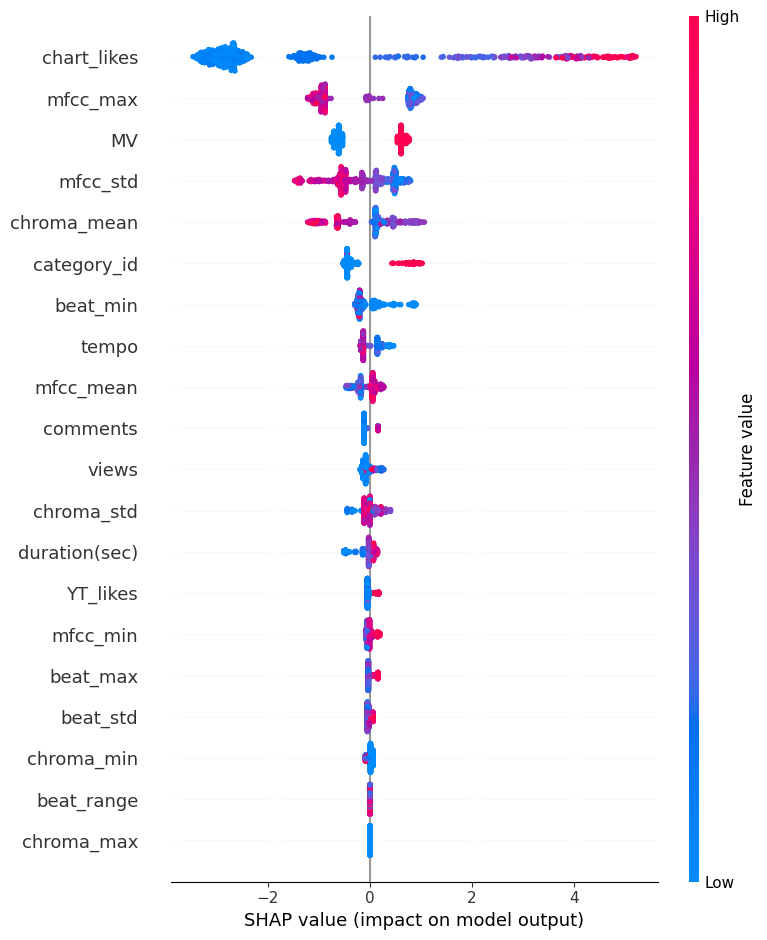

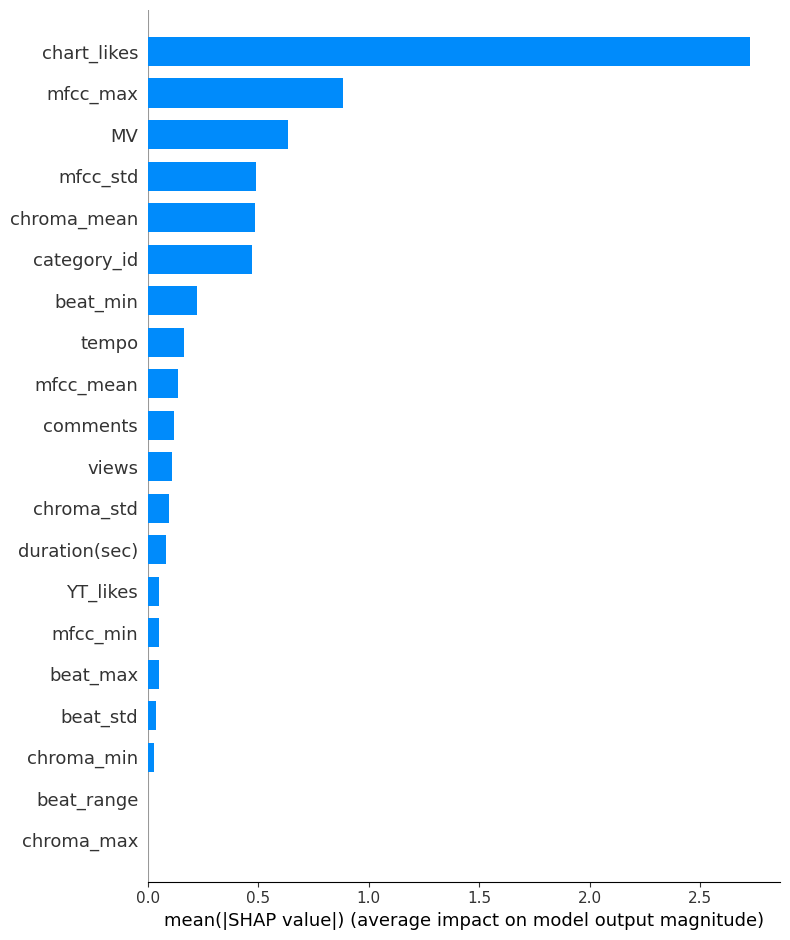

In [31]:
# Split the data into features (X) and target (y)
X = df[['views','chart_likes','MV','category_id', 'YT_likes', 'comments', 'duration(sec)',
        'tempo', 'beat_max', 'beat_min', 'beat_mean', 'beat_range', 'beat_std', 'chroma_mean', 'chroma_min', 'chroma_max', 'chroma_range', 'chroma_std',
        'mfcc_mean', 'mfcc_std', 'mfcc_min', 'mfcc_max']]
y = df['top10']

# Split the data into training and testing sets
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Split the data into training and testing sets based on 'ChartIn_Date'
X_train = X[df['ChartIn_Date'].dt.year.between(2020, 2021)]
y_train = y[df['ChartIn_Date'].dt.year.between(2020, 2021)]
X_test = X[df['ChartIn_Date'].dt.year.between(2022, 2023)]
y_test = y[df['ChartIn_Date'].dt.year.between(2022, 2023)]

# Train the model
model = xgb.XGBClassifier()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("Classification Report:")
print(report)

# SHAP feature importance
explainer = shap.Explainer(model)
shap_values = explainer.shap_values(X)
shap.summary_plot(shap_values, X)

# SHAP summary bar plot
shap.summary_plot(shap_values, X, plot_type='bar')

# Show the plot
plt.show()

RMSE: 21.987537007391122
MAPE: 1.1660717575828432
R2 Score: 0.4831035085895141
~tempo

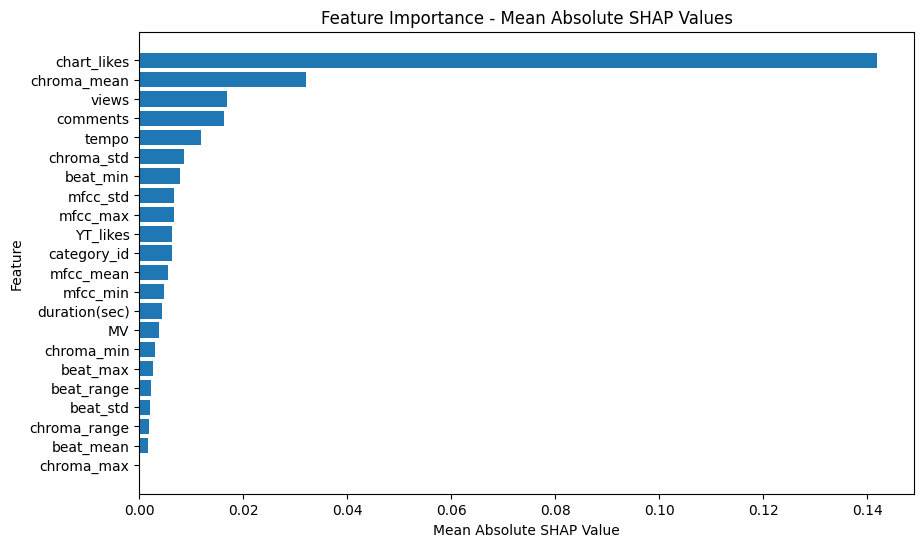

In [32]:
# Assume you have your feature matrix X and target variable y

# Train a Random Forest model
model = RandomForestRegressor()
model.fit(X, y)

# Initialize the SHAP explainer with the trained model
explainer = shap.Explainer(model)

# Calculate SHAP values for all features
shap_values = explainer.shap_values(X)

# Create a bar plot of the mean absolute SHAP values
mean_abs_shap = np.abs(shap_values).mean(axis=0)
feature_names = np.array(X.columns)
sorted_indices = np.argsort(mean_abs_shap)
sorted_feature_names = feature_names[sorted_indices]
sorted_mean_abs_shap = mean_abs_shap[sorted_indices]

plt.figure(figsize=(10, 6))
plt.barh(sorted_feature_names, sorted_mean_abs_shap)
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Feature Importance - Mean Absolute SHAP Values")

# Display the plots
plt.show()

RMSE: 33.25859449280708
MAPE: 3.5998156506695915
R2 Score: -0.1826553517885101


ntree_limit is deprecated, use `iteration_range` or model slicing instead.
No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


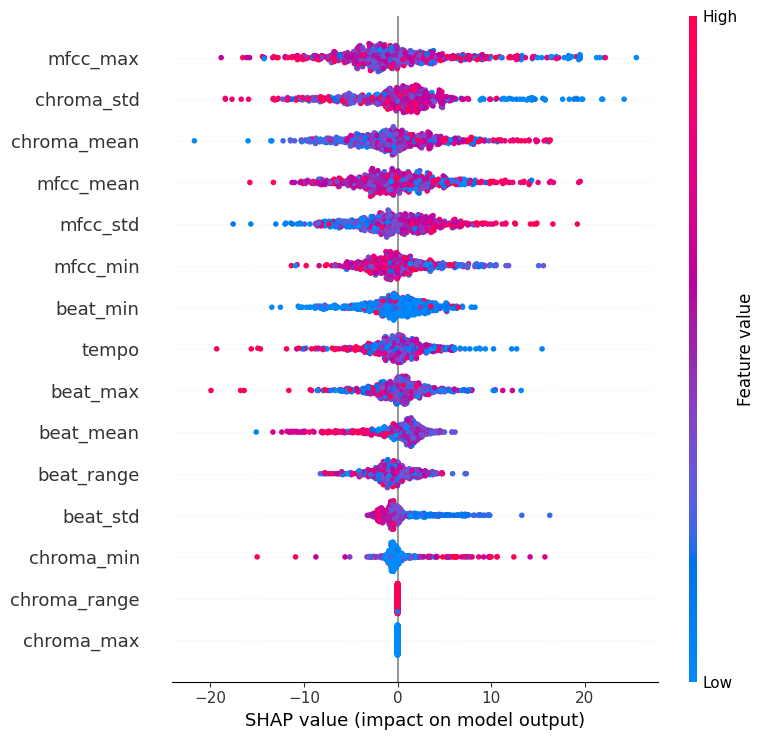

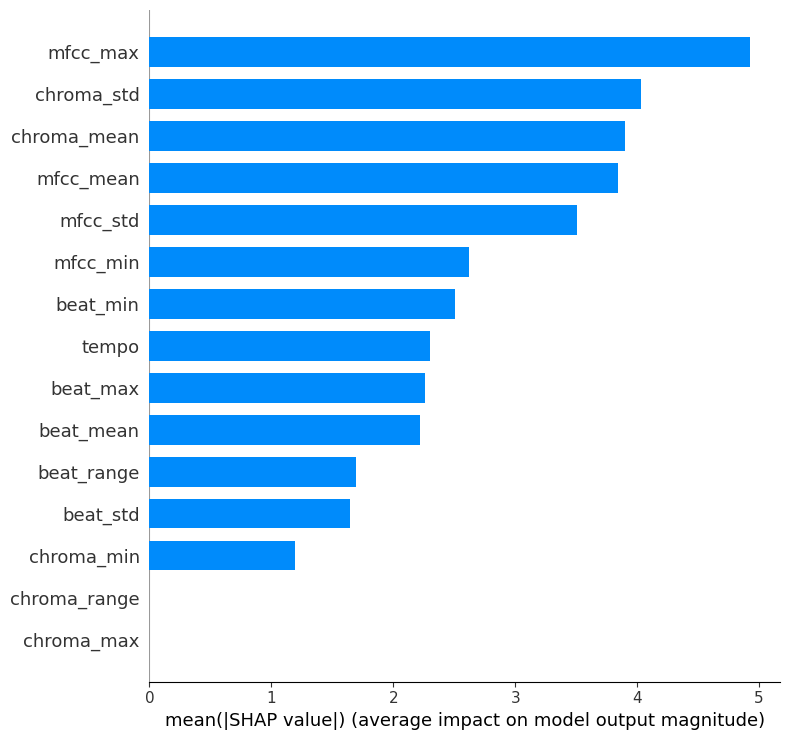

In [33]:
X = df[['tempo', 'beat_max', 'beat_min', 'beat_mean', 'beat_range', 'beat_std', 'chroma_mean', 'chroma_min', 'chroma_max', 'chroma_range', 'chroma_std',
        'mfcc_mean', 'mfcc_std', 'mfcc_min', 'mfcc_max']]
y = df['Top_Rank']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model = xgb.XGBRegressor()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate metrics
rmse = mean_squared_error(y_test, y_pred, squared=False)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAPE:", mape)
print("R2 Score:", r2)

# SHAP feature importance
explainer = shap.Explainer(model)
shap_values = explainer.shap_values(X)
shap.summary_plot(shap_values, X)

# SHAP summary bar plot
shap.summary_plot(shap_values, X, plot_type='bar')

# Show the plot
plt.show()

# Chroma/ MFCC visualization

In [34]:
df[df['artist'] == '10CM'].sort_values('chartIns', ascending=False)

,title,artist,Top_Rank,chartIns,chart_likes,top10,Video_id,MV,release_date,category_id,...,chroma_max,chroma_range,chroma_std,mfcc_mean,mfcc_std,mfcc_min,mfcc_max,duration(sec),ChartIn_Date,days_to_chart
141,폰서트,10CM,4,67,215388,1,mOo8bVzN9M8,1.0,2017-09-01,10,...,1.0,1.000000,0.319492,0.822267,49.742767,-495.053833,237.445038,253.0,2017-09-01,0
143,pet,10CM,15,57,86133,0,F4K1mMDlsj0,1.0,2017-09-04,10,...,1.0,1.000000,0.312857,-0.968211,49.384705,-488.560120,215.247040,244.0,2017-09-01,0
257,매트리스,10CM,3,43,105710,1,seNNCbiXTSY,1.0,2018-08-23,10,...,1.0,1.000000,0.321092,-1.670874,60.237209,-510.193085,256.842285,178.0,2018-09-01,31
302,그러나,10CM,2,24,80718,1,hNnoi32CyrA,1.0,2019-03-07,10,...,1.0,1.000000,0.307551,-3.095006,58.044510,-489.949585,234.405869,237.0,2019-03-01,0
142,HELP,10CM,8,17,56501,1,LnT9LmmlLXw,1.0,2017-08-28,10,...,1.0,1.000000,0.303763,0.610417,49.160564,-502.717163,222.161865,353.0,2017-09-01,31
529,그라데이션,10CM,1,9,142825,1,VQZXXciZb_c,1.0,2022-07-03,24,...,1.0,1.000000,0.305615,1.033930,51.983109,-468.271545,211.806564,218.0,2022-07-01,0
457,입김,10CM,18,7,27640,0,4QqF4wGhngI,1.0,2020-12-23,24,...,1.0,1.000000,0.320493,-1.683079,58.623180,-494.917480,221.780334,284.0,2021-01-01,31
437,Tight,10CM,12,6,27264,0,-xm5GpFwHw4,1.0,2020-09-22,24,...,1.0,1.000000,0.316993,-3.606642,53.743427,-485.418213,233.560883,249.0,2020-10-01,30
499,열심히 할게,10CM,63,2,13936,0,GPNNZ5toogk,0.0,2021-11-11,10,...,1.0,0.998842,0.313902,0.361912,53.665714,-485.840790,233.938599,226.0,2021-11-01,0
305,Storage (with Galaxy Fan),10CM,33,1,10730,0,4brbgpXEN40,1.0,2019-03-07,10,...,1.0,1.000000,0.328917,-1.931151,56.519009,-480.987762,218.737625,226.0,2019-03-01,0


In [35]:
# Assuming the dataframe is named 'df'
df_filtered = df[df['Top_Rank'] == 1].sort_values('chartIns', ascending=False)

# Print the filtered dataframe
df_filtered

,title,artist,Top_Rank,chartIns,chart_likes,top10,Video_id,MV,release_date,category_id,...,chroma_max,chroma_range,chroma_std,mfcc_mean,mfcc_std,mfcc_min,mfcc_max,duration(sec),ChartIn_Date,days_to_chart
432,오래된 노래,스탠딩 에그,1,75,255159,1,NFfPxExTyYA,0.0,2022-06-08,10,...,1.0,0.998622,0.293091,2.884312,46.571262,-518.993286,224.736984,273.0,2020-09-01,-638
184,비행운,문문 (MoonMoon),1,72,223140,1,dkdoawhm0i4,0.0,2021-02-15,10,...,1.0,1.000000,0.327123,-1.981803,60.738094,-486.797363,205.452118,179.0,2018-01-01,-1127
160,선물,멜로망스,1,69,344362,1,qYYJqWsBb1U,1.0,2017-07-10,10,...,1.0,1.000000,0.305914,2.985253,53.490356,-483.184570,222.496368,259.0,2017-11-01,123
150,썸 탈꺼야,볼빨간사춘기,1,67,213681,1,hZmoMyFXDoI,1.0,2017-09-28,10,...,1.0,1.000000,0.306053,0.965559,46.867661,-490.643250,235.098145,187.0,2017-10-01,30
225,여행,볼빨간사춘기,1,59,291144,1,xRbPAVnqtcs,1.0,2018-05-24,10,...,1.0,1.000000,0.301632,3.478628,50.972805,-484.481293,248.051086,258.0,2018-06-01,31
251,Way Back Home,숀 (SHAUN),1,57,355126,1,amOSaNX7KJg,1.0,2018-12-07,22,...,1.0,1.000000,0.308720,-0.360376,52.283516,-493.145294,213.855850,217.0,2018-08-01,-122
426,Downtown Baby,블루 (BLOO),1,55,202144,1,P07XG1P0ums,1.0,2017-12-13,10,...,1.0,1.000000,0.285362,5.084716,53.144932,-490.456482,227.875824,212.0,2020-06-01,913
344,오늘도 빛나는 너에게 (To You My Light) (Feat.이라온),마크툽 (MAKTUB),1,46,277145,1,dmSUBdk4SY4,0.0,2019-06-10,24,...,1.0,1.000000,0.303915,1.860120,48.304810,-484.527771,221.380356,266.0,2019-08-01,61
408,어떻게 지내 (Prod. By VAN.C),오반,1,37,196778,1,mXekvk0JEzk,1.0,2020-03-05,10,...,1.0,0.999710,0.311465,1.634424,43.722691,-452.254761,212.012085,231.0,2020-04-01,31
415,나비와 고양이 (feat.백현 (BAEKHYUN)),볼빨간사춘기,1,35,176539,1,L8UUYfe6-UA,1.0,2020-05-07,24,...,1.0,1.000000,0.304821,0.685909,47.406326,-485.799957,233.540054,204.0,2020-05-01,0


In [36]:
df_filtered_1 = df[df['Top_Rank'] == 99].sort_values('chartIns', ascending=False)
df_filtered_1

,title,artist,Top_Rank,chartIns,chart_likes,top10,Video_id,MV,release_date,category_id,...,chroma_max,chroma_range,chroma_std,mfcc_mean,mfcc_std,mfcc_min,mfcc_max,duration(sec),ChartIn_Date,days_to_chart
44,그날,어쿠루브,99,1,13130,0,NY3vqnrhqHk,0.0,2017-11-10,22,...,1.0,1.000000,0.310467,-1.570849,53.055882,-481.669708,198.542999,199.0,2017-01-01,-304
76,PLASTIC (Feat. 비와이_BewhY),정준일,99,1,27802,0,Z7ZVCnoRNIQ,1.0,2016-01-13,24,...,1.0,1.000000,0.310133,1.481948,60.133354,-473.150879,232.531570,276.0,2017-03-01,425
105,D.O.N,창모 (CHANGMO),99,1,22312,0,nQeJJWPN6Mw,0.0,2019-07-04,10,...,1.0,0.999355,0.309380,2.956633,38.807457,-464.678345,217.461090,231.0,2017-05-01,-791
120,혜야,검정치마,99,1,25867,0,B5cvbwOmfY0,0.0,2021-01-18,10,...,1.0,0.999500,0.291021,1.742761,61.958553,-480.455048,232.372925,325.0,2017-06-01,-1310
195,Vineyard (빈야드),우효,99,1,56749,0,ztKqa7jkN4s,0.0,2014-07-21,10,...,1.0,1.000000,0.303261,2.682114,58.408768,-499.437256,235.528275,205.0,2018-01-01,1280
381,Girls,정준일,99,1,4247,0,F1uuwM3HV8I,0.0,2019-10-30,10,...,1.0,1.000000,0.290752,5.822038,49.186409,-483.079163,236.544098,283.0,2019-11-01,31
414,아주 가끔은,어쿠스틱 콜라보,99,1,3064,0,mTbpMsZRx48,0.0,2020-03-30,10,...,1.0,0.999379,0.311712,-0.479466,45.410347,-509.278107,211.159607,214.0,2020-04-01,31
482,달이 참 예쁘다고,이승윤,99,1,36981,0,eNovSMOZ3VQ,0.0,2018-09-12,10,...,1.0,1.000000,0.295436,-4.401773,60.531940,-523.473145,223.417679,275.0,2021-07-01,1034


##Picked

In [37]:
import librosa

In [38]:
audio_path='/content/drive/MyDrive/2023-01/경영ai캡스톤/오디오/D.O.N [TubeRipper.com].wav'
y, sr = librosa.load(audio_path, sr=44100)
#/content/drive/MyDrive/2023-01/경영ai캡스톤/오디오/[MV] Nautilus(노틸러스) _ If(우연히 마주친다면) [TubeRipper.com].wav
#/content/drive/MyDrive/2023-01/경영ai캡스톤/오디오/뭐라할까! [TubeRipper.com].wav
#/content/drive/MyDrive/2023-01/경영ai캡스톤/오디오/코발트 블루 [TubeRipper.com].wav

#/content/drive/MyDrive/2023-01/경영ai캡스톤/오디오/숀 (SHAUN) - 웨이백홈 (Way Back Home) [Lyric Video] [TubeRipper.com].wav
#/content/drive/MyDrive/2023-01/경영ai캡스톤/오디오/[MV] MeloMance(멜로망스) _ Gift(선물) [TubeRipper.com].wav
#/content/drive/MyDrive/2023-01/경영ai캡스톤/오디오/Old Song (오래된 노래) [TubeRipper.com].wav
#/content/drive/MyDrive/2023-01/경영ai캡스톤/오디오/[MV] BOL4(볼빨간사춘기) _ Some(썸 탈꺼야) [TubeRipper.com].wav

In [39]:
tempo, beat_frames = librosa.beat.beat_track(y=y, sr=sr)
chromagram = librosa.feature.chroma_stft(y=y, sr=sr)
mfcc = librosa.feature.mfcc(y=y, sr=sr)

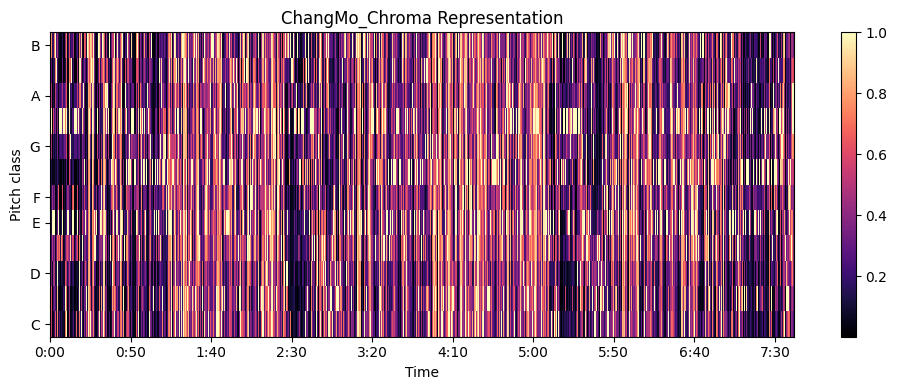

In [40]:
import librosa.display
# Plot the chroma features
plt.figure(figsize=(10, 4))
librosa.display.specshow(chromagram, y_axis='chroma', x_axis='time')
plt.colorbar()
plt.title('ChangMo_Chroma Representation')
plt.tight_layout()
plt.show()

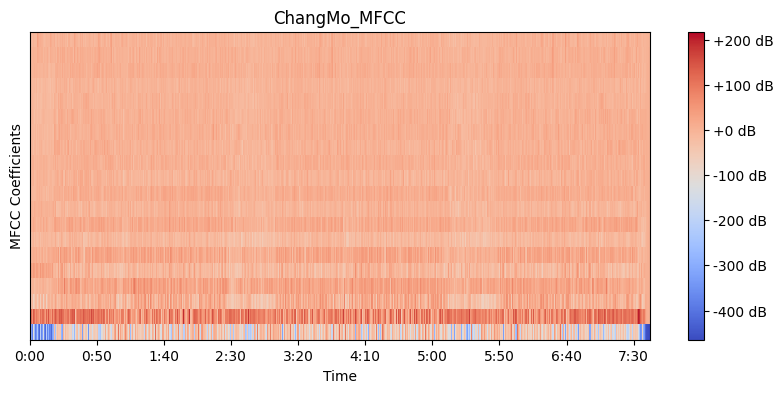

In [41]:
plt.figure(figsize=(10, 4))
librosa.display.specshow(mfcc, x_axis='time')

# Add a colorbar to the figure
plt.colorbar(format='%+2.0f dB')
# Set the title and labels of the plot
plt.title('ChangMo_MFCC')
plt.xlabel('Time')
plt.ylabel('MFCC Coefficients')
# Display the plot
plt.show()


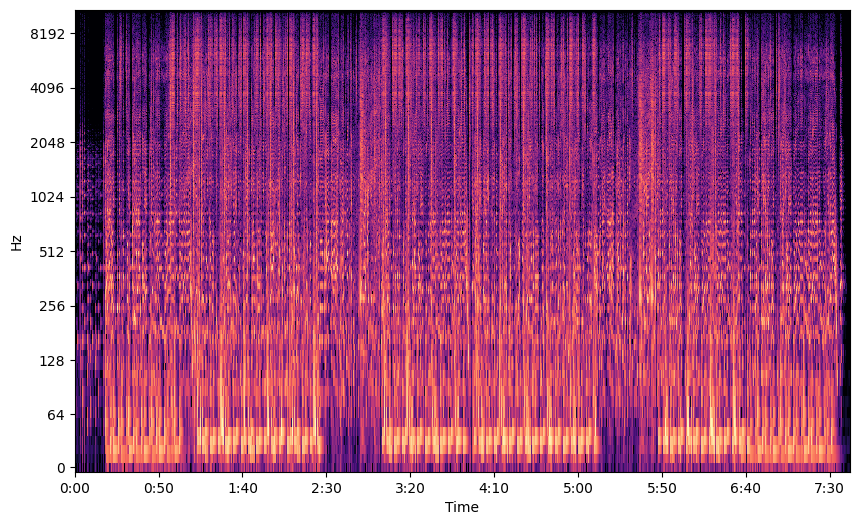

In [42]:
# Compute the spectrogram of the audio
spectrogram = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
# Plot the spectrogram
plt.figure(figsize=(10, 6))
librosa.display.specshow(spectrogram, x_axis='time', y_axis='log')
plt.show()